In [28]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit


# <div align="center">**The Planet in a Box: An Energy Balance Model of Global Warming**</div>

### <div align="center">MOD300 Mandatory project 2 </div>

<div align="center">Written by Jone Bakken & Petter Worpvik Tverdal</div>

<br>

<div align="center">! dato !</div>

### Abstract

### Introduction

## 1. Fundamentals of the two-box model

intro to exercise. what will we explore and why?

### 1.1 Visualizing the model


### 1.2 Checking the units

### 1.3

### 1.4

### 1.5

### 1.6

## 2. Building the ODE solver

## 3. First attempt – fitting a CO2-only model to real data

In [25]:
# Temp functions:

class TwoBoxModel:
    def __init__(self):
        self.C = 7.3
        self.C0 = 106.0
        self.lam = 1.13
        self.gamma = 0.73


def ebm_rhs(y, t, model, forcing):
    T, T0 = y

    F = forcing(t)

    dT_dt = (
        F
        - model.lam * T
        - model.gamma * (T - T0)
    ) / model.C

    dT0_dt = (
        model.gamma * (T - T0)
    ) / model.C0

    return np.array([dT_dt, dT0_dt])


def rk4(f, y0, t, *args):
    y0 = np.array(y0, dtype=float)

    result = np.zeros((len(t), len(y0)))
    result[0] = y0

    for i in range(len(t) - 1):
        h = t[i + 1] - t[i]

        y = result[i]
        current_t = t[i]

        k1 = f(y, current_t, *args)
        k2 = f(y + h*k1/2, current_t + h/2, *args)
        k3 = f(y + h*k2/2, current_t + h/2, *args)
        k4 = f(y + h*k3, current_t + h, *args)

        result[i + 1] = y + h/6 * (
            k1 + 2*k2 + 2*k3 + k4
        )

    return result


def solve_reference(f, y0, t, *args):

    def scipy_rhs(time, state):
        return f(state, time, *args)

    sol = solve_ivp(
        scipy_rhs,
        (t[0], t[-1]),
        y0,
        method="Radau",
        t_eval=t,
        rtol=1e-8,
        atol=1e-10
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol.y.T

### 3.1 

The CO₂ forcing is given by

$$
F = 5.35 \ln\left(\frac{CO_2}{280}\right)
$$

where $CO_2$ is the concentration in ppm, and 280 ppm is the pre-industrial reference value.

The forcing law is logarithmic. This means that the forcing depends on the relative increase in CO₂, rather than only how many ppm are added.

If the CO₂ concentration doubles from 280 ppm to 560 ppm, the forcing becomes

$$
F = 5.35 \ln\left(\frac{560}{280}\right)
$$

$$
F = 5.35 \ln(2)
$$

$$
F \approx 3.71 \text{ W/m}^2
$$

If the CO₂ concentration doubles again from 560 ppm to 1120 ppm, the increase in forcing is also

$$
5.35 \ln(2) \approx 3.71 \text{ W/m}^2
$$

This shows that every doubling of CO₂ gives the same increase in radiative forcing.

The coefficient 5.35 must have units of $\text{W/m}^2$, because the ratio $CO_2/280$ has no units, so the logarithm also has no units.

This is different from a linear forcing law. In a linear model, adding the same amount of CO₂, for example 100 ppm, would always give the same increase in forcing. In the logarithmic model, it is the same proportional increase, such as doubling the CO₂ concentration, that gives the same increase in forcing.

### 3.2


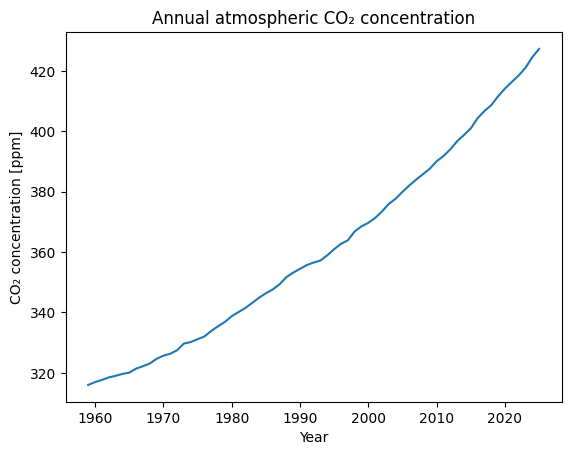

In [39]:
co2_data = pd.read_csv("data/co2_annual.dat", sep=r"\s+")
temp_data = pd.read_csv("data/gistemp_annual.dat", sep=r"\s+")



co2_year = co2_data["Year"]
co2_ppm = co2_data["CO2_ppm"]

plt.plot(co2_year, co2_ppm)
plt.xlabel("Year")
plt.ylabel("CO₂ concentration [ppm]")
plt.title("Annual atmospheric CO₂ concentration")
plt.show()

# Interpolating function using numpy
def co2_at_time(t):
    return np.interp(t, co2_year, co2_ppm)

# Equation (3): finding forcing from CO2 concentration
def co2_forcing_at_time(t):
    co2 = co2_at_time(t)
    return 5.35 * np.log(co2 / 280.0)



The CO₂ record shows an increasing atmospheric CO₂ concentration from 1959
to 2025. Since the ODE solver can evaluate the model at times between the
yearly measurements, linear interpolation is used to estimate the CO₂
concentration at any time $t$. This value is then used in equation (3) to
calculate the radiative forcing.

### 3.3

In [ ]:

temp_fit = temp_data[
    (temp_data["Year"] >= 1959) &
    (temp_data["Year"] <= 2025)
]

t_data = temp_fit["Year"].to_numpy()
T_data_obs = temp_fit["Anomaly_C"].to_numpy()

y0 = [T_data_obs[0], T_data_obs[0]]



In [49]:
model = TwoBoxModel()

def model_temperature(t, lam, gamma):
    model.lam = lam
    model.gamma = gamma

    solution = solve_reference(
        ebm_rhs,
        y0,
        t,
        model,
        co2_forcing_at_time
    )

    return solution[:, 0]

popt, pcov = curve_fit(
    model_temperature,
    t_data,
    T_data_obs,
    p0=[1.13, 0.73],
    method="trf",
    diff_step=1e-3,
    x_scale="jac",
    max_nfev=2000,
)

fitted_lam = popt[0]
fitted_gamma = popt[1]

In [36]:
T_model = model_temperature(
    t_data,
    fitted_lam,
    fitted_gamma
)

In [41]:
rmse = np.sqrt(np.mean((T_model - T_data_obs)**2))


In [ ]:
F2x = 5.35 * np.log(2)
ecs = F2x / fitted_lam

In [43]:
print(f"Fitted lambda: {fitted_lam:.2f} W/(m²K)")
print(f"Fitted gamma: {fitted_gamma:.2f} W/(m²K)")
print(f"RMSE: {rmse:.3f} °C")
print(f"ECS: {ecs:.2f} °C")

Fitted lambda: -1.22 W/(m²K)
Fitted gamma: 50857.19 W/(m²K)
RMSE: 0.108 °C
ECS: -3.05 °C


The unrestricted fit gave approximately

$$
\lambda = -1.22 \text{ W/(m}^2\text{K)}
$$

and

$$
\gamma = 5.09 \times 10^4 \text{ W/(m}^2\text{K)}.
$$

The RMSE was approximately $0.108^\circ C$, which means that the model can
fit the observed temperatures reasonably closely. However, the fitted
parameters are not physically meaningful. The fitted value of $\lambda$ is
negative, while it represents radiative damping in the model, and the fitted
value of $\gamma$ is extremely large compared with the default value of
$0.73$.

The fitted value of $\lambda$ gives an ECS of approximately

$$
ECS = -3.05^\circ C,
$$

which is also not physically reasonable for this model. This shows that a
small fitting error does not necessarily mean that the fitted parameters have
a realistic physical interpretation.

### 3.4

In [50]:
model = TwoBoxModel()

def model_temperature_lam(t, lam):
    model.lam = lam
    model.gamma = 0.73

    solution = solve_reference(
        ebm_rhs,
        y0,
        t,
        model,
        co2_forcing_at_time
    )

    return solution[:, 0]

In [51]:
popt_lam, pcov_lam = curve_fit(
    model_temperature_lam,
    t_data,
    T_data_obs,
    p0=[1.13],
    bounds=(1e-6, 5.4),
    method="trf",
    diff_step=1e-3,
    x_scale="jac",
    max_nfev=2000,
)

fitted_lam_2 = popt_lam[0]

In [52]:
T_model_2 = model_temperature_lam(
    t_data,
    fitted_lam_2
)

rmse_2 = np.sqrt(
    np.mean((T_model_2 - T_data_obs)**2)
)

F2x = 5.35 * np.log(2)
ecs_2 = F2x / fitted_lam_2

print(f"Fitted lambda: {fitted_lam_2:.2f}")
print(f"RMSE: {rmse_2:.3f} °C")
print(f"ECS: {ecs_2:.2f} °C")

Fitted lambda: 2.09
RMSE: 0.209 °C
ECS: 1.77 °C


The fitted value of $\lambda = 2.09$ W/(m²K) gives an ECS of approximately
$1.77^\circ C$. This is below the IPCC AR6 likely range of
$2.5$–$4^\circ C$ given in the assignment. This suggests that although the
CO₂-only model follows the general warming trend, the fitted climate
sensitivity is lower than the expected range.

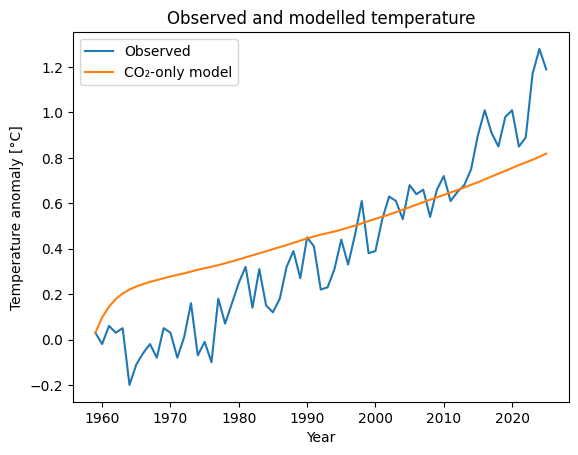

In [47]:
plt.plot(t_data, T_data_obs, label="Observed")
plt.plot(t_data, T_model_2, label="CO₂-only model")

plt.xlabel("Year")
plt.ylabel("Temperature anomaly [°C]")
plt.title("Observed and modelled temperature")
plt.legend()

plt.show()

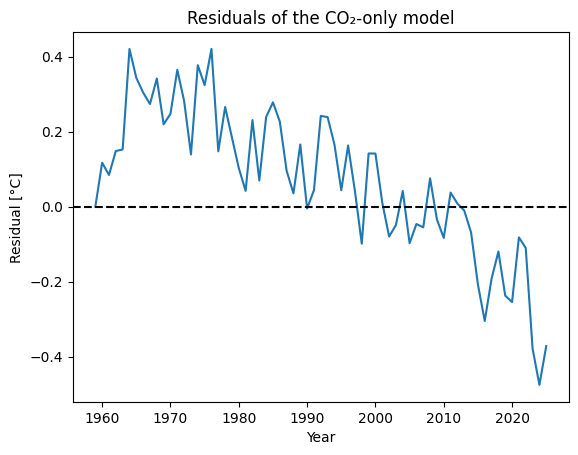

In [48]:
residuals = T_model_2 - T_data_obs

plt.plot(t_data, residuals)
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Year")
plt.ylabel("Residual [°C]")
plt.title("Residuals of the CO₂-only model")

plt.show()



The CO₂-only model captures the general warming trend from 1959 to 2025, but it does not match the observed temperature very well during all periods. The model gives a smooth increase in temperature, while the observed temperature has much more variation from year to year.

The residual plot shows that the errors are systematic rather than random. In the earlier part of the period, especially around the 1960s to 1980s, the residuals are mostly positive. Since the residual is defined as

$$
r(t) = T_{model}(t) - T_{data}(t),
$$

this means that the model generally predicts a higher temperature than what was observed during this period.

Around the 1990s and 2000s, the residuals are closer to zero, meaning that the model agrees better with the observations. Towards the most recent years, the residuals become mostly negative. This means that the observed temperature is increasing faster than the CO₂-only model predicts.

The clear pattern in the residuals suggests that CO₂ forcing alone does not explain all of the observed temperature changes. There are probably other effects missing from the model that change over time.

## 4. Aerosol cooling

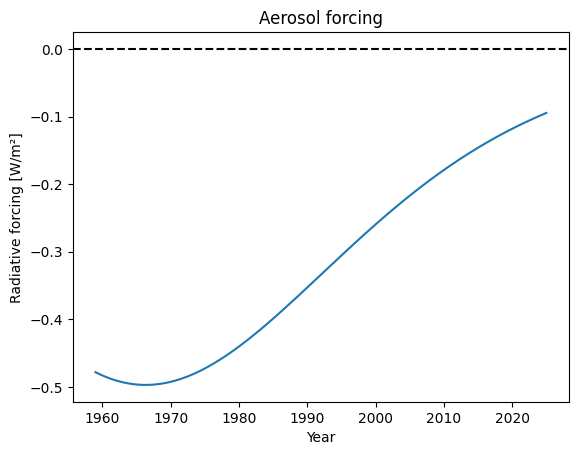

Strongest aerosol forcing: -0.49714589693658223
Year: 1966.4068136272545


In [56]:
def aerosol_forcing(t, B):
    rise = 1 / (1 + np.exp(-(t - 1950) / 15))
    fall = 1 / (1 + np.exp((t - 1980) / 20))

    return -B * rise * fall

B = 1

t = np.linspace(1959, 2025, 500)

F_aerosol = aerosol_forcing(t, B)

plt.plot(t, F_aerosol)
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Year")
plt.ylabel("Radiative forcing [W/m²]")
plt.title("Aerosol forcing")

plt.show()

index = np.argmin(F_aerosol)

print("Strongest aerosol forcing:", F_aerosol[index])
print("Year:", t[index])


The two fractions in the aerosol forcing equation are dimensionless.
Therefore, $B$ must have units of W/m² so that
$F_{\text{aerosol}}$ also has units of W/m².

For $B=1$ W/m², the aerosol forcing has its largest magnitude around
1966, where it is approximately $-0.50$ W/m².

I expect the temperature trajectory to change the most during the middle part
of the record, around the 1960s to 1980s. This is where the aerosol forcing is
strongest and most negative, so it reduces the total radiative forcing the most.

Therefore, the model should predict lower temperatures in this period compared
with the CO₂-only model. The effect on temperature may also continue for some
time after the strongest aerosol forcing because the climate system does not
respond instantly.

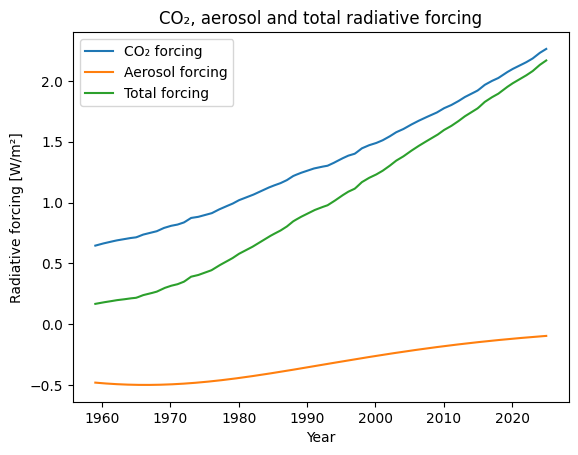

In [58]:
F_co2 = co2_forcing_at_time(t)
F_total = F_co2 + F_aerosol

plt.plot(t, F_co2, label="CO₂ forcing")
plt.plot(t, F_aerosol, label="Aerosol forcing")
plt.plot(t, F_total, label="Total forcing")

plt.xlabel("Year")
plt.ylabel("Radiative forcing [W/m²]")
plt.title("CO₂, aerosol and total radiative forcing")
plt.legend()

plt.show()

### 4.2

In [59]:
def model_temperature_aerosol(t, gamma, B):
    model.lam = 1.13
    model.gamma = gamma

    def total_forcing(time):
        return (
            co2_forcing_at_time(time)
            + aerosol_forcing(time, B)
        )

    solution = solve_reference(
        ebm_rhs,
        y0,
        t,
        model,
        total_forcing
    )

    return solution[:, 0]

In [61]:
popt_aerosol, pcov_aerosol = curve_fit(
    model_temperature_aerosol,
    t_data,
    T_data_obs,
    p0=[0.73, 1.0],
    bounds=(
        [0.1, 0.0],
        [2.0, 3.0]
    ),
    method="trf",
    diff_step=1e-3,
    x_scale="jac",
    max_nfev=2000
)

fitted_gamma = popt_aerosol[0]
fitted_B = popt_aerosol[1]

In [63]:
T_aerosol = model_temperature_aerosol(
    t_data,
    fitted_gamma,
    fitted_B
)

rmse_aerosol = np.sqrt(
    np.mean((T_aerosol - T_data_obs)**2)
)


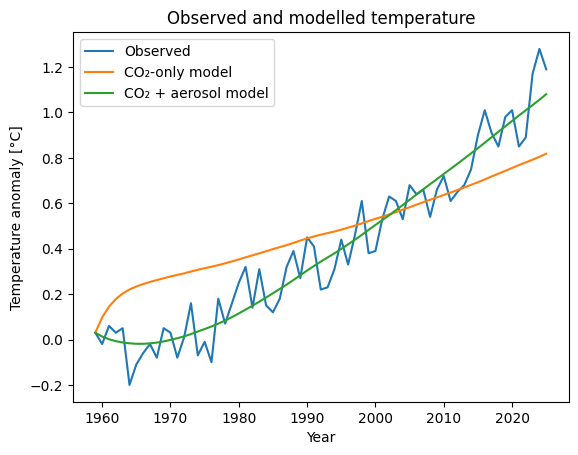

In [ ]:
plt.plot(t_data, T_data_obs, label="Observed")

plt.plot(t_data, T_model_2, label="CO₂-only model")

plt.plot(t_data, T_aerosol, label="CO₂ + aerosol model")

plt.xlabel("Year")
plt.ylabel("Temperature anomaly [°C]")
plt.title("Observed and modelled temperature")
plt.legend()

plt.show()

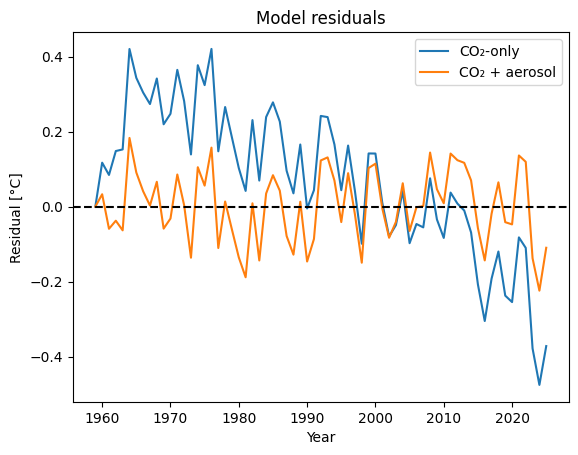

In [ ]:
residuals_aerosol = T_aerosol - T_data_obs

plt.plot(t_data, residuals, label="CO₂-only")

plt.plot(t_data, residuals_aerosol, label="CO₂ + aerosol")

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Year")
plt.ylabel("Residual [°C]")
plt.title("Model residuals")
plt.legend()

plt.show()

In [64]:
print("Fitted gamma:", fitted_gamma)
print("Fitted B:", fitted_B)
print("RMSE:", rmse_aerosol)

Fitted gamma: 0.8049465750733005
Fitted B: 1.5823276995706335
RMSE: 0.09560981597481963


As shown in the figures above, the CO₂ + aerosol model represents the observed
temperature data more accurately than the CO₂-only model. The residuals also
have less of a clear systematic pattern and are generally closer to zero.

The fitted values were

$$
\gamma \approx 0.80 \text{ W/(m}^2\text{K)}
$$

and

$$
B \approx 1.58 \text{ W/m}^2,
$$

with an RMSE of approximately $0.096^\circ C$.

The fitted value of $\gamma$ also seems reasonable since it is fairly close to
the default value of 0.73. The positive value of $B$ means that the aerosol
forcing gives a cooling effect, which is the physical effect we expected when
adding aerosols to the model.

Therefore, the aerosol model seems to be an improvement over the CO₂-only
model. The aerosol cooling helps explain some of the temperature variation
that the CO₂-only model was not able to reproduce.

However, the better fit does not prove that this specific aerosol model is
correct. The aerosol forcing used here is only an approximate model, and adding
another fitted parameter also gives the model more flexibility to match the
observations. The improved RMSE and residuals show that the added forcing can
explain some of the missing behaviour, but they do not prove that the chosen
aerosol forcing is the true explanation.

## 5.

## Summary

---
---

### Reflection
